# Package

In [2]:
from pathlib import Path
import pandas as pd
from feast import FeatureStore

from eda_utils import plot_acf_pacf_stationary

In [3]:
# --------------------------------------------------
# Init Feast
# --------------------------------------------------
REPO_PATH = (
    Path.cwd().parent
    / "2_data_processing"
    / "feature_store"
    / "feast_repo"
    / "feature_repo"
)

store = FeatureStore(repo_path=str(REPO_PATH))

# --------------------------------------------------
# Définir univers temporel
# --------------------------------------------------
dates = pd.date_range(
    start="1960-01-01",
    end="2025-09-01",
    freq="MS",
)

# --------------------------------------------------
# Series IDs (option 1 : explicite, OK pour maintenant)
# --------------------------------------------------
series_ids = [
    "BUSLOANS","CPIAUCSL","DPCERA3M086SBEA","INDPRO",
    "M2SL","OILPRICEX","RPI","SP500","TB3MS","UNRATE","USREC",
]

entity_df = pd.MultiIndex.from_product(
    [series_ids, dates],
    names=["series_id", "date"],
).to_frame(index=False)

# --------------------------------------------------
# Récupération Feast
# --------------------------------------------------
df_stationary = store.get_historical_features(
    entity_df=entity_df,
    features=["stationary_value:value"],
).to_df()

# --------------------------------------------------
# LONG → WIDE
# --------------------------------------------------
df_wide = (
    df_stationary
    .rename(columns={"stationary_value__value": "value"})
    .pivot(index="date", columns="series_id", values="value")
    .sort_index()
)

df = df_wide.copy()

df.head()

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.


series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
1960-01-01 00:00:00+00:00,0.011578,-0.006156,0.001204,0.091976,0.001323,0.0,0.020977,0.017909,0.30,-0.8,0.0
1960-02-01 00:00:00+00:00,0.011905,-0.003767,0.006009,0.076960,0.002007,0.0,0.014565,-0.025663,-0.19,-1.1,0.0
1960-03-01 00:00:00+00:00,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.0,0.006250,-0.070857,-1.18,-0.2,0.0
1960-04-01 00:00:00+00:00,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.0,0.006489,-0.040442,-1.12,0.0,0.0
1960-05-01 00:00:00+00:00,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.0,0.007747,-0.010090,-0.67,0.0,1.0


# Information dans le passé de UNRATE

## Est-ce qu'il y a des informations dans le passé de UNRATE pour modéliser avec une Auto-régresive? 

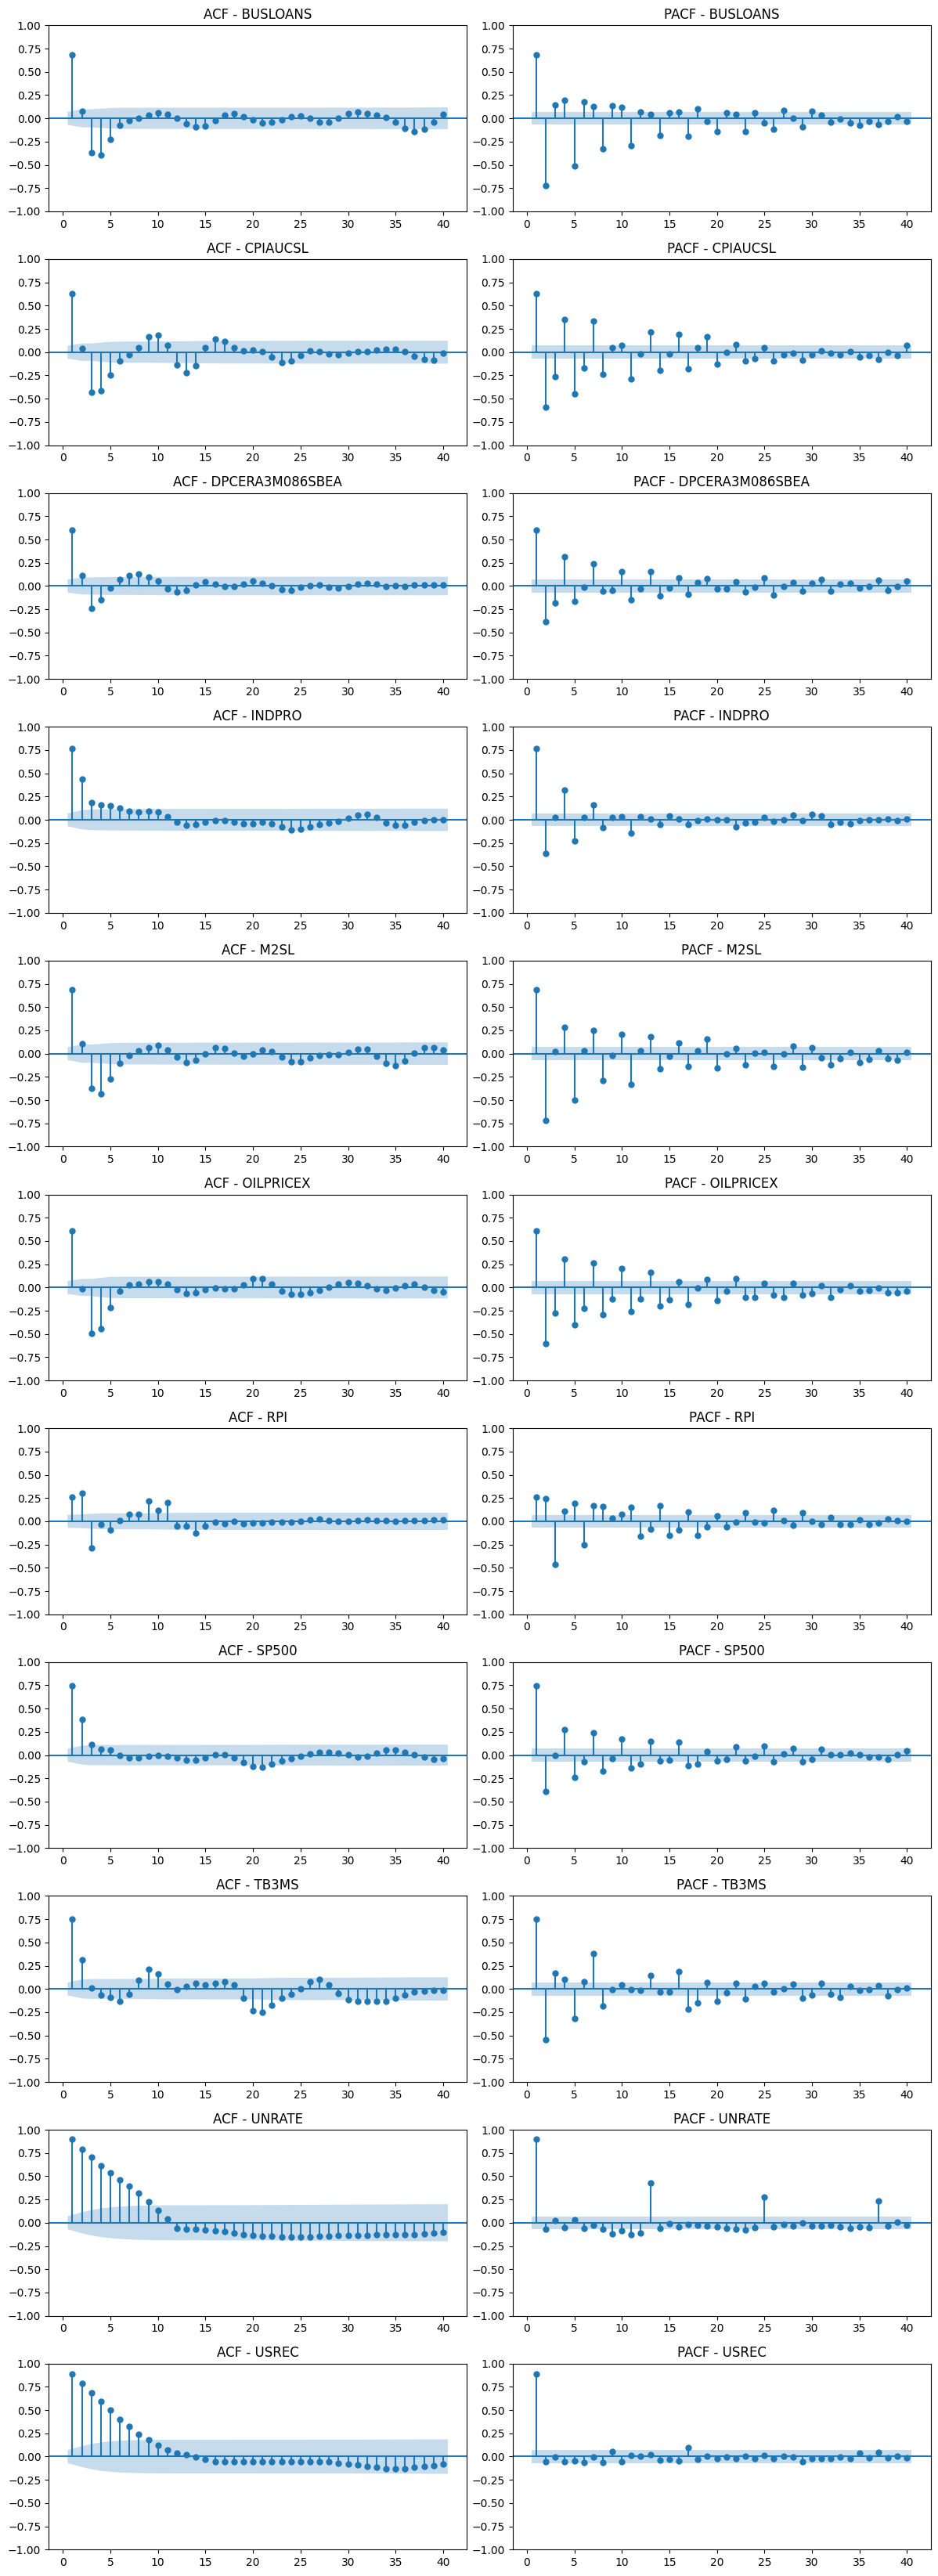

In [6]:
# ----------------------------
# ACF / PACF
# ----------------------------
plot_acf_pacf_stationary(
    df,
    lags=40,
    min_n=30,
    zero=False
)

## Règle d'interprétation
ACF : indique combien longtemps le passé influence le présent (mémoire).

PACF : indique quels retards comptent réellement (effet direct).


ACF qui décroît lentement → forte persistance

PACF avec quelques pics nets → dépendance concentrée sur peu de retards

Comme le PACF ne suggère pas un ordre AR unique clair au-delà de 1,
et qu’un effet saisonnier annuel apparaît,
on teste empiriquement des AR courts (p = 1 à 8)
puis p = 12 pour capturer l’effet annuel,
et on tranche par backtesting et critères d’information.

# Conclusion
Un modèle Auto-régressif serait notre baseline. 
Experiment 5_1 et 5_2

Nous avons vu que cette approche est insuffisante. Il faut donc choisir des variables exogènes pour expliquer l'évolution du chômage. 

Il est plus facile de trouver les variables explicatives dans l'approche traditionnelle. Il suffit juste de sélectionner les variables avec des techniques comme ACP, régularisation LASSO, etc.

Le plus grand problème cependant, dès sélectionne nos variables sur ces techniques, on empêche notre expérimentation de trouver éventuellement des relations non linéaires. Puisque ces techniques de sélection elles-mêmes sont fondées sur l'hypothèse de linéarité. 

Notre stratégie de sélection de variables se basent donc la confrontation des théories économiques, l'histoire des Etats-Unis et les données. 

Vous pourriez vous demander s’il faut sélectionner les variables une à une.
Dans un premier temps, nous procédons à une sélection manuelle d’un nombre restreint de variables (environ une dizaine), sur lesquelles repose la première phase d’expérimentation.

Dans un second temps, l’ensemble des variables est injecté dans le processus expérimental. Les modèles linéaires assurent alors une sélection des variables pertinentes d’un point de vue linéaire, tandis que les modèles de Machine Learning permettent de capturer des relations non linéaires entre les variables.

L’objectif est d’analyser si ces deux approches convergent vers des résultats similaires, ou si la seconde phase met en évidence des variables ou des dynamiques jusqu’alors non prises en compte.

# Crisis

In [7]:
import pandas as pd

# Série USREC (index = date, valeur = 0/1)
usrec = df["USREC"].copy()

# Détection des débuts et fins de crise
crisis_start = (usrec == 1) & (usrec.shift(1) == 0)
crisis_end   = (usrec == 1) & (usrec.shift(-1) == 0)

# Table des périodes de crise
crises = pd.DataFrame({
    "start": usrec.index[crisis_start],
    "end": usrec.index[crisis_end]
})

# Durée en mois
crises["duration_months"] = (
    (crises["end"].dt.to_period("M") - crises["start"].dt.to_period("M"))
    .apply(lambda x: x.n + 1)
)

crises

C:\Users\Mita\AppData\Local\Temp\ipykernel_6932\1339061582.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  (crises["end"].dt.to_period("M") - crises["start"].dt.to_period("M"))


,start,end,duration_months
0,1960-05-01 00:00:00+00:00,1961-02-01 00:00:00+00:00,10
1,1970-01-01 00:00:00+00:00,1970-11-01 00:00:00+00:00,11
2,1973-12-01 00:00:00+00:00,1975-03-01 00:00:00+00:00,16
3,1980-02-01 00:00:00+00:00,1980-07-01 00:00:00+00:00,6
4,1981-08-01 00:00:00+00:00,1982-11-01 00:00:00+00:00,16
5,1990-08-01 00:00:00+00:00,1991-03-01 00:00:00+00:00,8
6,2001-04-01 00:00:00+00:00,2001-11-01 00:00:00+00:00,8
7,2008-01-01 00:00:00+00:00,2009-06-01 00:00:00+00:00,18
8,2020-03-01 00:00:00+00:00,2020-04-01 00:00:00+00:00,2


In [23]:
import plotly.graph_objects as go

# ----------------------------
# 1) Données
# ----------------------------
mid_dates = crises["start"] + (crises["end"] - crises["start"]) / 2
top3_idx = crises["duration_months"].nlargest(3).index

colors = ["red" if i in top3_idx else "gray" for i in crises.index]
sizes = crises["duration_months"] * 40

crisis_names = {
    "1960-05-01": "Récession 1960–61",
    "1970-01-01": "Récession 1970",
    "1973-12-01": "Choc pétrolier 1973–75",
    "1980-02-01": "Récession 1980",
    "1981-08-01": "Récession 1981–82",
    "1990-08-01": "Récession 1990–91",
    "2001-03-01": "Crise Internet (dot-com)",
    "2007-12-01": "Crise des subprimes",
    "2020-02-01": "Crise du Covid-19",
}

# ----------------------------
# 2) Hover uniquement
# ----------------------------
descriptions = []
for i, row in crises.iterrows():
    start_str = row["start"].strftime("%Y-%m")
    end_str = row["end"].strftime("%Y-%m")
    key = row["start"].strftime("%Y-%m-%d")
    name = crisis_names.get(key, "Crise économique")

    top_tag = " (TOP 3)" if i in top3_idx else ""
    descriptions.append(
        f"<b>{name}</b>{top_tag}<br>"
        f"Période : {start_str} → {end_str}<br>"
        f"Durée : {row['duration_months']} mois"
    )

# ----------------------------
# 3) Plot
# ----------------------------
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=mid_dates,
        y=[1] * len(crises),
        mode="markers",  # ✅ PAS de texte affiché
        marker=dict(size=sizes, color=colors, opacity=0.85, sizemode="area"),
        hovertext=descriptions,  # ✅ texte seulement au survol
        hovertemplate="%{hovertext}<extra></extra>",
        showlegend=False,
    )
)

fig.update_layout(
    title="Crises US : timing et durée (top 3 en rouge)",
    xaxis_title="Année",
    yaxis=dict(visible=False, range=[0.9, 1.1]),
    template="plotly_dark",
    height=420,
    width=900,
)

fig.show()

En termes de durrée, les trois crises les plus persistantes Etats-Unis après 1960 sont : 
- les deux premiers chocs pétroliers (70s et 80s) ; 
- La crise de Subprime de 2008 ; 
- La crise de Coronavirus (2020) a été très vite résorbée par l'économie.

La crise de pétrole signifie baisse drastique du cours du pétrol. Nous devrons donc tenir en compte du prix du baril du pétrol dans nos modèles. Il capte les chocs centraux globaux. Si le chômage est liée à l'indicateur de récession (voir analyse bivariée).

La crise des subprimes correspond à une rupture du canal du crédit. La dégradation des prêts a provoqué un credit crunch. Normalement, celà freine l’investissement et la consommation. Cet effet multiplicateur entraine la persistance de la dégradation de la performance économique. 

Le BUSLOANS est donc une variable très important dans nos expérimentations. 

# Conclusion

Voici donc les variables qui ressortent immédiatement de nos analyses de crise : 
- prix de baril du pétrol ; 
- Crédit bancaire aux entreprises ;

Il faut faire une analyse bivariée de la relation entre taux de chômage et récession. 